# **Space X  Falcon 9 First Stage Landing Prediction**


## Machine Learning Prediction


Space X advertises Falcon 9 rocket launches on its website with a cost of 62 million dollars; other providers cost upward of 165 million dollars each, much of the savings is because Space X can reuse the first stage. Therefore if I can determine if the first stage will land, I can determine the cost of a launch. This information can be used if an alternate company wants to bid against space X for a rocket launch.   

In this notebook, I created a machine learning pipeline  to predict if the first stage will land given the data from the preceding notebooks.


Illustration of Falcon 9 first stage landing successfully

![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/landing_1.gif)


Here are also several examples of unsuccessful landings:


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/crash.gif)


However, most unsuccessful landings are planed, and Space X performs a controlled landing in the oceans.


## Objectives


Performing exploratory  Data Analysis and determining Training Labels

*   Creating a column for the class
*   Standardizing the data
*   Spliting into training data and test data

Finding the best Hyperparameter for SVM, Classification Trees and Logistic Regression

*   Finding the method that performs best using test data


## Importing Libraries and Defining Functions


Importing the required libraries:


In [95]:
import warnings
warnings.filterwarnings('ignore')
# Pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
# NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns
# Preprocessing allows us to standarsize our data
from sklearn import preprocessing
# Allows us to split our data into training and testing data
from sklearn.model_selection import train_test_split
# Allows us to test parameters of classification algorithms and find the best one
from sklearn.model_selection import GridSearchCV
# Logistic Regression classification algorithm
from sklearn.linear_model import LogisticRegression
# Support Vector Machine classification algorithm
from sklearn.svm import SVC
# Decision Tree classification algorithm
from sklearn.tree import DecisionTreeClassifier
# K Nearest Neighbors classification algorithm
from sklearn.neighbors import KNeighborsClassifier

Creating a function to plot the confusion matrix.


In [96]:
def plot_confusion_matrix(y,y_predict):
    "this function plots the confusion matrix"
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y, y_predict)
    ax= plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix'); 
    ax.xaxis.set_ticklabels(['did not land', 'land']); ax.yaxis.set_ticklabels(['did not land', 'landed']) 
    plt.show() 

 Loading the dataframe


In [97]:
data = pd.read_csv("dataset_part_2.csv") # Dataset exported from the Data Wrangling notebook

In [98]:
data.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6123.547647,LEO,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [99]:
X = pd.read_csv("dataset_part_3.csv") # Dataset exported from the EDA with Data Visualization notebook

In [100]:
X.head(10)

,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,Orbit_LEO,Orbit_MEO,Orbit_PO,Orbit_SO,Orbit_SSO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


Creating a NumPy array from the column <code>Class</code> in <code>data</code>, by applying the method <code>to_numpy()</code>. Then
assigned it  to the variable <code>Y</code>.


In [101]:
Y= pd.Series(data["Class"].to_numpy())
Y.head(5)

0    0
1    0
2    0
3    0
4    0
dtype: int64

Standardizing the data in <code>X</code> then reassigning it to the variable  <code>X</code> using the <code>StandardScaler</code>.


In [102]:
transform = preprocessing.StandardScaler()
X= transform.fit_transform(X)

I splited the data into training and testing data using the  function  <code>train_test_split</code>.  The training data is divided into validation data, a second set used for training  data; then the models are trained and hyperparameters are selected using the function <code>GridSearchCV</code>.


Setting the parameter test_size to  0.2 and random_state to 2.

In [103]:
X_train, X_test, Y_train, Y_test= train_test_split(X, Y, test_size=0.2, random_state=2)

There are only have 18 test samples.

In [104]:
Y_test.shape

(18,)

Creating a logistic regression object, then creating a  GridSearchCV object  <code>logreg_cv</code> with cv = 10.  Fited the object to find the best parameters from the dictionary <code>parameters</code>.


In [105]:
parameters ={"C":[0.01,0.1,1],'penalty':['l2'], 'solver':['lbfgs']} # l1 lasso l2 ridge
lr=LogisticRegression()
logreg_cv= GridSearchCV(lr, parameters, cv=10)
logreg_cv.fit(X_train, Y_train)

,estimator,LogisticRegression()
,param_grid,"{'C': [0.01, 0.1, ...], 'penalty': ['l2'], 'solver': ['lbfgs']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


Outputing the <code>GridSearchCV</code> object for logistic regression. I have displayed the best parameters using the data attribute <code>best_params\_</code> and the accuracy on the validation data using the data attribute <code>best_score\_</code>.

In [106]:
print("tuned hpyerparameters :(best parameters) ", logreg_cv.best_params_)
print("accuracy :", np.round(logreg_cv.best_score_, 3))

tuned hpyerparameters :(best parameters)  {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
accuracy : 0.696


Calculating the accuracy on the test data using the method <code>score</code>:


In [107]:
logreg_accuracy= logreg_cv.score(X_test, Y_test)
print(f"Score: {np.round(logreg_accuracy, 3)}") 

Score: 0.778


Taking a look at the confusion matrix:


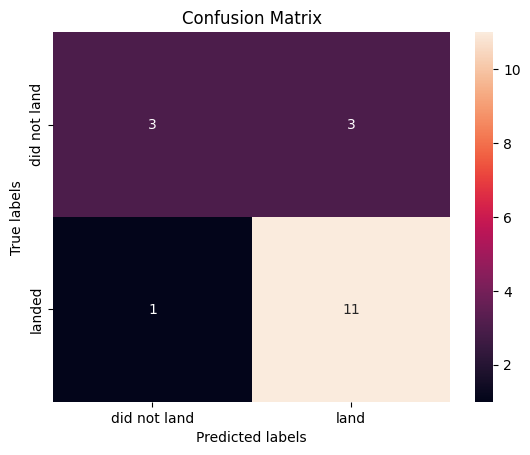

In [108]:
logreg_yhat=logreg_cv.predict(X_test)
plot_confusion_matrix(Y_test,logreg_yhat)

Examining the confusion matrix, I can see that logistic regression can distinguish between the different classes, but the problem is false positives.

Overview:

True Postive - 11 (True label is landed, Predicted label is also landed)

False Postive - 3 (True label is not landed, Predicted label is landed)


Creating a support vector machine object. Then,  creating a  <code>GridSearchCV</code> object  <code>svm_cv</code> with cv = 10.  Fited the object to find the best parameters from the dictionary <code>parameters</code>.


In [109]:
parameters = {'kernel':('linear', 'rbf','poly','rbf', 'sigmoid'),
              'C': np.logspace(-3, 3, 5),
              'gamma':np.logspace(-3, 3, 5)}
svm = SVC()

In [110]:
svm_cv = GridSearchCV(svm, parameters, cv=10)
svm_cv.fit(X_train, Y_train)

,estimator,SVC()
,param_grid,"{'C': array([1.0000...00000000e+03]), 'gamma': array([1.0000...00000000e+03]), 'kernel': ('linear', ...)}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,np.float64(31.622776601683793)


In [111]:
print("tuned hpyerparameters :(best parameters) ",svm_cv.best_params_)
print("accuracy :", np.round(svm_cv.best_score_, 3))

tuned hpyerparameters :(best parameters)  {'C': np.float64(31.622776601683793), 'gamma': np.float64(0.03162277660168379), 'kernel': 'sigmoid'}
accuracy : 0.796


Calculating the accuracy on the test data using the method <code>score</code>:

In [112]:
svm_accuracy= svm_cv.score(X_test, Y_test)
print(f"Score: {np.round(svm_accuracy, 3)}")

Score: 0.944


Ploting the confusion matrix


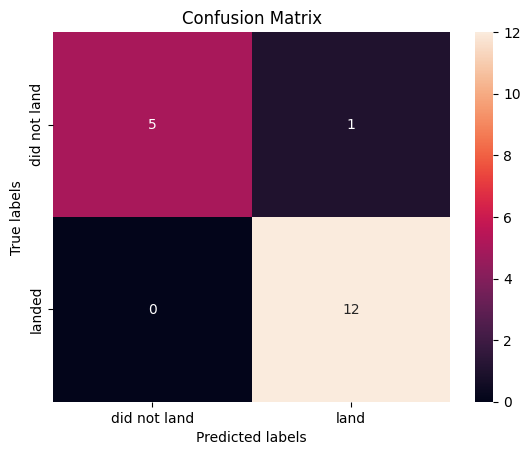

In [113]:
svm_yhat=svm_cv.predict(X_test)
plot_confusion_matrix(Y_test,svm_yhat)

Creating a decision tree classifier object. Then,  creating a  <code>GridSearchCV</code> object  <code>tree_cv</code> with cv = 10.  Fited the object to find the best parameters from the dictionary <code>parameters</code>.


In [114]:
parameters = {'criterion': ['gini', 'entropy'],
     'splitter': ['best', 'random'],
     'max_depth': [2*n for n in range(1,10)],
     'max_features': ['auto', 'sqrt'],
     'min_samples_leaf': [1, 2, 4],
     'min_samples_split': [2, 5, 10]}

tree = DecisionTreeClassifier()

In [115]:
tree_cv= GridSearchCV(tree, parameters, cv=10)
tree_cv.fit(X_train, Y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [2, 4, ...], 'max_features': ['auto', 'sqrt'], 'min_samples_leaf': [1, 2, ...], ...}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [116]:
print("tuned hpyerparameters :(best parameters) ",tree_cv.best_params_)
print("accuracy :", np.round(tree_cv.best_score_, 3))

tuned hpyerparameters :(best parameters)  {'criterion': 'entropy', 'max_depth': 16, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'splitter': 'random'}
accuracy : 0.789


Calculating the accuracy of tree_cv on the test data using the method <code>score</code>:


In [117]:
tree_accuracy= tree_cv.score(X_test, Y_test)
print(f"Score: {np.round(tree_accuracy, 3)}")

Score: 0.667


Ploting the confusion matrix


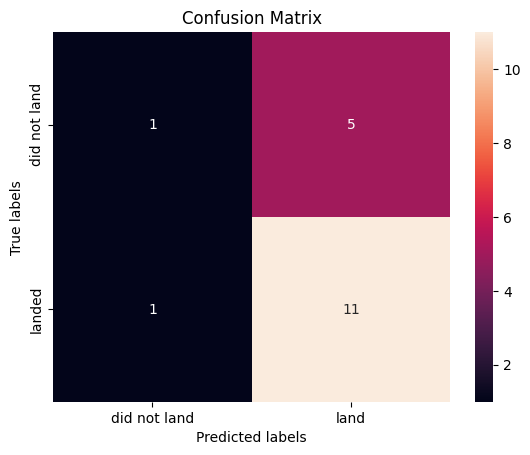

In [118]:
tree_yhat = tree_cv.predict(X_test)
plot_confusion_matrix(Y_test,tree_yhat)

Creating a k nearest neighbors object. Then, creating a  <code>GridSearchCV</code> object  <code>knn_cv</code> with cv = 10.  Fited the object to find the best parameters from the dictionary <code>parameters</code>.


In [119]:
parameters = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
              'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
              'p': [1,2]}

KNN = KNeighborsClassifier()

In [120]:
knn_cv= GridSearchCV(KNN, parameters, cv=10)
knn_cv.fit(X_train, Y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'algorithm': ['auto', 'ball_tree', ...], 'n_neighbors': [1, 2, ...], 'p': [1, 2]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,10


In [121]:
print("tuned hpyerparameters :(best parameters) ",knn_cv.best_params_)
print("accuracy :", np.round(knn_cv.best_score_, 3))

tuned hpyerparameters :(best parameters)  {'algorithm': 'auto', 'n_neighbors': 10, 'p': 1}
accuracy : 0.739


Calculating the accuracy of knn_cv on the test data using the method <code>score</code>:


In [122]:
knn_accuracy = knn_cv.score(X_test, Y_test)
print(f"Score: {np.round(knn_accuracy, 3)}")

Score: 0.722


Ploting the confusion matrix


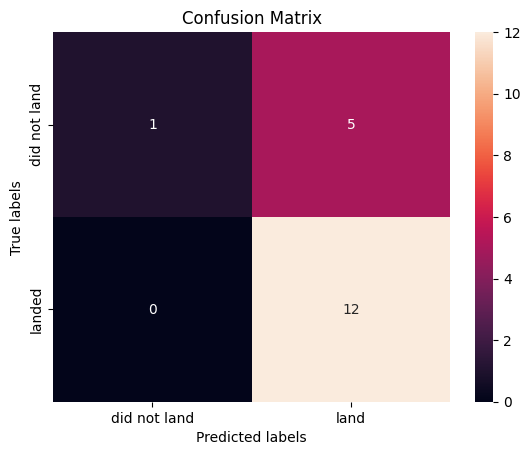

In [123]:
knn_yhat = knn_cv.predict(X_test)
plot_confusion_matrix(Y_test,knn_yhat)

Finding which method performs the best:


In [124]:
# Examining the scores from Test sets
from sklearn.metrics import jaccard_score, f1_score

jaccard_scores = [
                  jaccard_score(Y_test, logreg_yhat, average='binary'),
                  jaccard_score(Y_test, svm_yhat, average='binary'),
                  jaccard_score(Y_test, tree_yhat, average='binary'),
                  jaccard_score(Y_test, knn_yhat, average='binary'),
                 ]

f1_scores = [
             f1_score(Y_test, logreg_yhat, average='binary'),
             f1_score(Y_test, svm_yhat, average='binary'),
             f1_score(Y_test, tree_yhat, average='binary'),
             f1_score(Y_test, knn_yhat, average='binary'),
            ]

accuracy = [logreg_accuracy, svm_accuracy, tree_accuracy, knn_accuracy]

scores = pd.DataFrame(np.array([jaccard_scores, f1_scores, accuracy]), index=['Jaccard_Score', 'F1_Score', 'Accuracy'] , columns=['LogReg', 'SVM', 'Tree', 'KNN'])
scores

,LogReg,SVM,Tree,KNN
Jaccard_Score,0.733333,0.923077,0.647059,0.705882
F1_Score,0.846154,0.960000,0.785714,0.827586
Accuracy,0.777778,0.944444,0.666667,0.722222


In [125]:
# Examining the scores from the whole Dataset
from sklearn.metrics import jaccard_score, f1_score

jaccard_scores = [
                  jaccard_score(Y, logreg_cv.predict(X), average='binary'),
                  jaccard_score(Y, svm_cv.predict(X), average='binary'),
                  jaccard_score(Y, tree_cv.predict(X), average='binary'),
                  jaccard_score(Y, knn_cv.predict(X), average='binary'),
                 ]

f1_scores = [
             f1_score(Y, logreg_cv.predict(X), average='binary'),
             f1_score(Y, svm_cv.predict(X), average='binary'),
             f1_score(Y, tree_cv.predict(X), average='binary'),
             f1_score(Y, knn_cv.predict(X), average='binary'),
            ]

accuracy = [logreg_cv.score(X, Y), svm_cv.score(X, Y), tree_cv.score(X, Y), knn_cv.score(X, Y)]

scores = pd.DataFrame(np.array([jaccard_scores, f1_scores, accuracy]),
                      index=['Jaccard_Score', 'F1_Score', 'Accuracy'],
                      columns=['LogReg', 'SVM', 'Tree', 'KNN'])
scores

,LogReg,SVM,Tree,KNN
Jaccard_Score,0.921875,0.906250,0.780822,0.740741
F1_Score,0.959350,0.950820,0.876923,0.851064
Accuracy,0.944444,0.933333,0.822222,0.766667


## Results
- Based on the scores of the whole Dataset, Logistic Regression seems a better model by 0.1 more accurracy.
  
- Based on the scores of the Test Set, SVM is the best model due to its highest accuracy.

## Author
- [Parshv Patel](https://www.linkedin.com/in/parshv-patel-65a90326b)

